#  Generative Adversarial Networks
Implementing the **Generator (G)** and **Discriminator (D)** modules. 
They update by turns in an adversarial training loop.

### Hyperparameters
| Parameter | Description |
|-----------|-------------|
| `batch_size` | Number of samples per training step |
| `neurons` | Width of each hidden layer |
| `num_epochs` | Training duration |
| `latent_d` | Dimensionality of the noise vector $z$ fed to G |
| `out_shape` | Target shape of generated images |

### Hardware target
- **GPU**: NVIDIA RTX 2080 Ti · 10.57 GB VRAM · Turing sm\_75
- **AMP / FP16**: enabled via `torch.amp.autocast` + `GradScaler`
- **CUDA 12.8** · **PyTorch 2.9.1+cu128** · **cuDNN 9.1.0**

In [3]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm

# Import dl_utils
import sys, os
sys.path.insert(0, os.path.abspath("../DL_utils_EZA"))
%load_ext autoreload
%autoreload 2
from dl_utils import *
print("dl_utils loaded ✅")

# ── Device setup ──────────────────────────────────────────────────────────────
# cudnn.benchmark = True  → optimal for fixed-size inputs (convolutional GANs)
# cudnn.benchmark = False → safer for FC-only GANs with variable shapes
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/tmp/ipykernel_17493/200592877.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


dl_utils loaded ✅
Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.35 GB


In [ ]:
# Hyperparameters
batch_size = 128
latent_d = 128
neurons = 512
out_shape = (-1,  28, 28)
num_epochs = 50

In [ ]:
# View class to conver the image shape
class View(nn.Module):
    def __init__(self, *shape):
        super(View, self).__init__()
        self.shape = shape
    def forward(self, input):
        return input.view(*self.shape) 
    

# FCLayer function
def fcLayer(in_neurons, out_neurons, leak=0.1):
    """ 
    in_neurons: number of input neurons
    out_neurons: number of output neurons
    leak: leakiness for leaky ReLU activation function
    """

    return nn.Sequential(
        nn.Linear(in_neurons, out_neurons),
        nn.LeakyReLU(leak),
        nn.LayerNorm(out_neurons)
    )

## Define the *GAN*
**Generator (G)**: maps a random noise vector $z \in \mathbb{R}^{latent\_d}$ → fake image.

**Discriminator (D)**: maps an image → scalar logit (real vs. fake).

> `nn.Sigmoid()` is appended to G only when `sigmoidG=True`, which constrains pixel values to $[0,1]$ — required for MNIST. Skip it for data already normalised to $[-1, 1]$ (use `tanh` instead) or for raw float outputs.

### GAN design recommendations
| Recommendation | Reason |
|----------------|--------|
| `LeakyReLU(α=0.1–0.2)` | Prevents dead neurons / vanishing gradients |
| `LayerNorm` over `BatchNorm` | Avoids mode collapse from noisy batch stats |
| `Adam(lr=1e-4, β₁=0, β₂=0.9)` | Standard GAN optimizer — low β₁ reduces momentum oscillation |
| `BCEWithLogitsLoss` | Numerically stable (no separate sigmoid) |

In [ ]:
# GAN code

def simpleGAN(latent_d: int, neurons: int, out_shape: tuple,
              sigmoidG: bool = False, leak: float = 0.2):
    """
    Build a fully-connected GAN for image generation.

    Parameters
    ----------
    latent_d  : int   — noise vector dimension (input to Generator)
    neurons   : int   — hidden layer width (same for G and D)
    out_shape : tuple — target image shape, e.g. (-1, 28, 28) for MNIST
    sigmoidG  : bool  — if True, add Sigmoid at end of G (use for [0,1] data)
    leak      : float — LeakyReLU negative slope

    Returns
    -------
    G : nn.Module — Generator
    D : nn.Module — Discriminator
    """
    # Number of pixels in one image (e.g. 28×28 = 784 for MNIST)
    flat_dim = abs(int(np.prod(out_shape)))   # ✅ consistent helper used in both G and D

    # ── Generator ─────────────────────────────────────────────────────────────
    # z (latent_d,) → 512 → 512 → 512 → 784 → reshape to (28,28)
    G = nn.Sequential(
        fcLayer(latent_d, neurons, leak),
        fcLayer(neurons,  neurons, leak),
        fcLayer(neurons,  neurons, leak),
        nn.Linear(neurons, flat_dim),
        View(out_shape)               # (-1, 28, 28)
    )
    if sigmoidG:
        G = nn.Sequential(G, nn.Sigmoid())

    # ── Discriminator ─────────────────────────────────────────────────────────
    # image (28,28) → flatten (784,) → 512 → 512 → 512 → 1 logit
    # ⚠️  BUG FIXED: was 'abs.prod(out_shape)' → AttributeError
    #    abs() is a Python built-in function, NOT an object with a .prod() method
    D = nn.Sequential(
        nn.Flatten(),
        fcLayer(flat_dim, neurons, leak),  # ✅ abs(np.prod(...)) → flat_dim
        fcLayer(neurons,  neurons, leak),
        fcLayer(neurons,  neurons, leak),
        nn.Linear(neurons, 1)             # raw logit — BCEWithLogitsLoss applies sigmoid internally
    )

    return G, D

### Recomendations when building GANs
- Use the LeakyReLU activation fucntion with large leak value $\alpha$ = 0.1 or 0.2; to avoid vanishing gradients
- Use LN instead of batch normalization. If troubleshooting use normalization only in the generator.
- use the Adam optimizer with learning_rate = 0.0001 and $\beta _{1}$ = 0 and $\beta _{2}$ = 0.9

In [ ]:
# ── Instantiate GAN ───────────────────────────────────────────────────────────
G, D = simpleGAN(latent_d, neurons, out_shape, sigmoidG=True)

# Quick sanity check — print parameter counts
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Generator     params : {count_params(G):,}")
print(f"Discriminator params : {count_params(D):,}")
print(f"Total GAN     params : {count_params(G) + count_params(D):,}")
print()

# Quick forward-pass smoke test before loading data
z_test = torch.randn(4, latent_d)             # batch of 4 noise vectors
fake_imgs = G(z_test)                          # G: (4, latent_d) → (4, 28, 28)
d_out     = D(fake_imgs.unsqueeze(1))          # D expects (B, C, H, W) if using Flatten
# Note: for a flat FC discriminator that uses nn.Flatten(), the input shape
# just needs to be flattenable — (B, 28, 28) works too.
# Let's test both shapes:
d_out_flat = D(fake_imgs)                      # (4, 28, 28) → Flatten → (4, 784)

print(f"Noise input shape   : {z_test.shape}")
print(f"G output shape      : {fake_imgs.shape}")
print(f"D output shape      : {d_out_flat.shape}")
print("\n✅ Smoke test passed — shapes are correct!")

In [ ]:
# ── MNIST DataLoader ──────────────────────────────────────────────────────────
# Normalise to [0, 1] to match sigmoidG=True output range
mnist_transform = transforms.Compose([
    transforms.ToTensor(),          # uint8 [0,255] → float32 [0,1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=mnist_transform
)

# num_workers=4 → matches your 4 physical CPU cores (HARDWARE.md)
# pin_memory=True → pages DataLoader tensors into pinned RAM for faster GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,      # 4 physical cores on your machine
    pin_memory=True,    # faster CPU→GPU transfer via Thunderbolt 3
    drop_last=True      # keeps batch size constant — important for LayerNorm stability
)

print(f"Training samples : {len(train_dataset):,}")
print(f"Batches/epoch    : {len(train_loader)}")
print(f"Batch size       : {batch_size}")

In [ ]:
# Implementing the GAN

# ── Training Setup ────────────────────────────────────────────────────────────
G.to(device)
D.to(device)

# BCEWithLogitsLoss = Sigmoid + BCELoss fused → numerically stable
# Never add a Sigmoid to D's output when using this loss
loss_func = nn.BCEWithLogitsLoss()

real_label = 1.0   # float labels work with BCEWithLogitsLoss
fake_label = 0.0

# Standard GAN optimizer recipe: lr=1e-4, β₁=0, β₂=0.9
optimizerD = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.0, 0.9))
optimizerG = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.0, 0.9))

# AMP scaler — leverages RTX 2080 Ti Tensor Cores for ~2× throughput
# Note: for FC-only GANs the speedup is smaller than for CNNs, but still worthwhile
use_amp = (device.type == 'cuda')
scaler  = torch.amp.GradScaler() if use_amp else None

print(f"AMP / FP16 training : {'✅ Enabled' if use_amp else '❌ Disabled (CPU)'}")

In [ ]:
# ── GAN Training Loop ─────────────────────────────────────────────────────────
#
# Each iteration does TWO gradient updates:
#   1. Update D → maximise its ability to distinguish real from fake
#   2. Update G → fool D (minimise D's confidence on fake images)
#
# Loss tracking: store per-epoch averages for plotting

history_lossD = []
history_lossG = []

for epoch in range(num_epochs):
    epoch_lossD = []
    epoch_lossG = []

    G.train()
    D.train()

    for real_imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
        # real_imgs shape: (B, 1, 28, 28) from MNIST DataLoader
        # Squeeze channel dim → (B, 28, 28) to match out_shape
        real_imgs = real_imgs.squeeze(1).to(device)   # (B, 28, 28)
        B = real_imgs.size(0)

        real_labels = torch.full((B, 1), real_label, device=device)
        fake_labels = torch.full((B, 1), fake_label, device=device)

        # ── Step 1: Update Discriminator ──────────────────────────────────────
        optimizerD.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            # Loss on real images (D should output → 1)
            pred_real = D(real_imgs)
            loss_real = loss_func(pred_real, real_labels)

            # Generate fake images (detach so G gradients don't flow here)
            z = torch.randn(B, latent_d, device=device)
            fake_imgs = G(z).detach()              # .detach() is critical!

            # Loss on fake images (D should output → 0)
            pred_fake = D(fake_imgs)
            loss_fake = loss_func(pred_fake, fake_labels)

            lossD = (loss_real + loss_fake) / 2    # average the two losses

        if scaler:
            scaler.scale(lossD).backward()
            scaler.step(optimizerD)
            scaler.update()
        else:
            lossD.backward()
            optimizerD.step()

        # ── Step 2: Update Generator ──────────────────────────────────────────
        optimizerG.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            z = torch.randn(B, latent_d, device=device)
            fake_imgs = G(z)                       # fresh forward pass (no detach)
            pred_fake = D(fake_imgs)

            # G wants D to predict REAL for its fakes → use real_labels
            lossG = loss_func(pred_fake, real_labels)

        if scaler:
            scaler.scale(lossG).backward()
            scaler.step(optimizerG)
            scaler.update()
        else:
            lossG.backward()
            optimizerG.step()

        epoch_lossD.append(lossD.item())
        epoch_lossG.append(lossG.item())

    avg_D = np.mean(epoch_lossD)
    avg_G = np.mean(epoch_lossG)
    history_lossD.append(avg_D)
    history_lossG.append(avg_G)

    print(f"Epoch [{epoch+1:02d}/{num_epochs}]  Loss D: {avg_D:.4f}  |  Loss G: {avg_G:.4f}")

print("\n✅ Training complete!")

In [ ]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history_lossD, label='Discriminator Loss', color='steelblue')
ax.plot(history_lossG, label='Generator Loss',     color='tomato')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAN Training Curves — MNIST')
ax.legend()
plt.tight_layout()
plt.show()

# ── Visualise Generated Images ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_d, device=device)
    samples = G(z).cpu().numpy()   # (16, 28, 28)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle(f'Generated samples after {num_epochs} epochs', fontsize=12)
plt.tight_layout()
plt.show()

## Mode Collapse
When the generator is only producing the *"easiest"* result, based on **mode** of the data distibution

In [ ]:
# Showing mode collapse
gausGrid = (3, 3)
samples_per = 10000
X = []
for i in range(gausGrid[0]):
    for j in range(gausGrid[1]):
        z = np.random.normal(0, 0.05, size=(samples_per, 2))  # Shift each cluster to a grid point
        z[:,0] += i/1.0-(gausGrid[0]-1)/2.0  # Center grid around origin
        z[:,1] += j/1.0-(gausGrid[1]-1)/2.0
        X.append(z)
X = np.vstack(X)

plt.figure(figsize=(6,6))
sns.kdeplot(x=X[:,0], y=X[:,1], fill=True, thresh=-0.001)
plt.title('Mode Collapse Example: 9 Gaussian Clusters')
plt.show()

**A collapsed GAN will only pick 2 or 3 clusters.**

## Wasserstein GAN (WGAN): Mitigating mode collapse
It is not using a sigmoid activation for the discriminator D. It helps with the vanshing gradients.\
Also he D should work harder to learn to help the G in the fight by introducing a **penalty on the complexity**.
### Implementing a WGAN-GP (Wassertein GAN with gradient penalty)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Gradient penalty — unchanged, always FP32
# ─────────────────────────────────────────────────────────────────────────────
def compute_gradient_penalty(D, real, fake, device):

 
            # ══════════════════════════════════════════════════════════
            # CRITIC UPDATE — runs every batch
            # ══════════════════════════════════════════════════════════
    batch_size = real.size(0)
    eps_shape  = [batch_size] + [1] * (real.dim() - 1)
    eps        = torch.rand(eps_shape, device=device)
    mixed      = (eps * real + (1.0 - eps) * fake).requires_grad_(True)
    output     = D(mixed)
    grad       = torch.autograd.grad(
        outputs=output, inputs=mixed,
        grad_outputs=torch.ones_like(output),
        create_graph=True, retain_graph=True, only_inputs=True,
    )[0]
    grad = grad.view(batch_size, -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

 
# ─────────────────────────────────────────────────────────────────────────────
# NOTE on AMP + Gradient Penalty
# ─────────────────────────────────────────────────────────────────────────────
# The gradient penalty requires autograd through D. Using autocast inside
# the GP computation can cause NaN gradients with FP16.
# Standard practice: run the GP computation in FP32 (outside autocast),
# keep the rest of the Critic and Generator forward passes in AMP.
# The implementation below follows this pattern.
 


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# train_wgan_gp — all bugs fixed
# ─────────────────────────────────────────────────────────────────────────────
def train_wgan_gp(G: nn.Module,
                  D: nn.Module,
                  loader: DataLoader,
                  latent_d: int,
                  epochs: int = 200,
                  device: str = 'cpu',
                  lambda_gp: float = 10.0,
                  n_critics: int = 5,
                  use_amp: bool = True) -> tuple:
    """
    Train a WGAN-GP.
 
    Parameters
    ----------
    G          : Generator  (nn.Module) — final activation should be Tanh
    D          : Critic     (nn.Module) — no sigmoid, no BatchNorm
    loader     : DataLoader — yields (data,) or (data, labels)
    latent_d   : int        — latent space dimensionality
    epochs     : int        — number of full passes over the dataset
    device     : str        — 'cuda' or 'cpu'
    lambda_gp  : float      — gradient penalty weight (standard = 10)
    n_critics  : int        — Critic updates per Generator update (standard = 5)
    use_amp    : bool       — FP16 via Tensor Cores (RTX 2080 Ti)
 
    Returns
    -------
    G_losses, D_losses : list[float], list[float]
        One value per batch for D; one value per Generator update for G.
 
    Bug fixes applied vs original:
        1. epoch_G.append — correct indentation (inside `if step % n_critics`)
        2. epoch_D.append — outside `if`, records every Critic batch      [was inside if]
        3. step += 1      — inside inner loop, increments per batch        [was per epoch]
        4. scaler.update() — paired after EACH optimizer.step()            [was only after G]
        5. G_losses.extend / D_losses.extend — lines were missing entirely [empty returns]
    """
    G_losses, D_losses = [], []
 
    G.to(device)
    D.to(device)
 
    optimizerD  = torch.optim.AdamW(D.parameters(), lr=1e-4, betas=(0.0, 0.9))
    optimizerG  = torch.optim.AdamW(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
    amp_enabled = use_amp and (device == 'cuda')
    scaler      = torch.amp.GradScaler() if amp_enabled else None
 
    step = 0  # counts batches, not epochs
 
    for epoch in range(epochs):
        epoch_G, epoch_D = [], []
 
        for data in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
 
            # ── Unpack batch ───────────────────────────────────────────
            if isinstance(data, (list, tuple)) and len(data) == 2:
                data, _ = data
            elif isinstance(data, (list, tuple)) and len(data) == 1:
                data = data[0]
 
            real       = data.to(device)
            batch_size = real.size(0)
 
            # ══════════════════════════════════════════════════════════
            # CRITIC UPDATE — runs every batch
            # ══════════════════════════════════════════════════════════
            optimizerD.zero_grad()
 
            with torch.no_grad():
                noise = torch.randn(batch_size, latent_d, device=device)
                fake  = G(noise).detach()
 
            D_real = D(real)
            D_fake = D(fake)
            gp     = compute_gradient_penalty(D, real, fake, device)  # always FP32
            errD   = (D_fake - D_real).mean() + lambda_gp * gp
 
            if scaler is not None:
                scaler.scale(errD).backward()
                scaler.step(optimizerD)
                scaler.update()                   # fix 4: paired with Critic step
            else:
                errD.backward()
                optimizerD.step()
 
            epoch_D.append(errD.item())           # fix 2: always recorded
 
            # ══════════════════════════════════════════════════════════
            # GENERATOR UPDATE — runs every n_critics batches
            # ══════════════════════════════════════════════════════════
            if step % n_critics == 0:
                optimizerG.zero_grad()
                noise = torch.randn(batch_size, latent_d, device=device)
 
                if amp_enabled:
                    with torch.amp.autocast(device_type='cuda'):
                        errG = -D(G(noise)).mean()
                else:
                    errG = -D(G(noise)).mean()
 
                if scaler is not None:
                    scaler.scale(errG).backward()
                    scaler.step(optimizerG)
                    scaler.update()               # fix 4: paired with Generator step
                else:
                    errG.backward()
                    optimizerG.step()
 
                epoch_G.append(errG.item())       # fix 1: correct indent
 
            step += 1                             # fix 3: per batch, not per epoch
 
        # ── Accumulate into outer lists ────────────────────────────────
        G_losses.extend(epoch_G)                  # fix 5: was missing entirely
        D_losses.extend(epoch_D)                  # fix 5: was missing entirely
 
        g_mean = sum(epoch_G) / len(epoch_G) if epoch_G else float('nan')
        d_mean = sum(epoch_D) / len(epoch_D)
        #print(f"Epoch {epoch+1:3d} | D: {d_mean:+.4f} | G: {g_mean:+.4f}")
 
    return G_losses, D_losses


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# Toy dataset helpers
# ─────────────────────────────────────────────────────────────────────────────
def make_gaussian_grid(grid=(3, 3), samples_per=10_000, std=0.05, spacing=1.0):
    X = []
    rows, cols = grid
    for i in range(rows):
        for j in range(cols):
            z       = np.random.normal(0, std, size=(samples_per, 2))
            z[:, 0] += i * spacing - (rows - 1) * spacing / 2.0
            z[:, 1] += j * spacing - (cols - 1) * spacing / 2.0
            X.append(z)
    return np.vstack(X)
 
 
def plot_kde(X, title='Gaussian Grid'):
    plt.figure(figsize=(6, 6))
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, thresh=0.0)
    plt.title(title)
    plt.tight_layout()
    plt.show()
 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    device     = 'cuda' if torch.cuda.is_available() else 'cpu'
    batch_size = 256
    latent_d   = 64
 
    # 1. Ground truth
    X = make_gaussian_grid(grid=(3, 3), samples_per=10_000, std=0.05)
    plot_kde(X, title='Target: 9 Gaussian Clusters (Ground Truth)')
 
    toy_dataset = TensorDataset(torch.tensor(X, dtype=torch.float32))
    toy_loader  = DataLoader(
        toy_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=(device == 'cuda'),
        num_workers=4,
        persistent_workers=True,
    )
 
    # 2. Architecture sanity check — run this BEFORE training
    G, D = simpleGAN(latent_d, 512, (-1, 2))
    with torch.no_grad():
        test_out = G(torch.randn(1000, latent_d))
    print("── Generator sanity check ──────────────────")
    print(f"  Output shape : {test_out.shape}")
    print(f"  Output range : [{test_out.min():.3f}, {test_out.max():.3f}]")
    print(f"  Output mean  : {test_out.mean(axis=0).tolist()}")
    print(f"  Target range : [-1.0, 1.0] (clusters at ±1.0 spacing)")
    # If range >> 2.0 → your Generator is missing a Tanh final activation.
    # Add nn.Tanh() as the last layer in the Generator.
 
    # 3. Train — increase epochs significantly for full mode coverage
    G_losses, D_losses = train_wgan_gp(
        G, D, toy_loader, latent_d,
        epochs=200,          # 20 is not enough; 200-500 for all 9 clusters
        device=device,
        lambda_gp=10.0,
        n_critics=5,
        use_amp=True,
    )
 
    # 4. Eval
    G.eval()
    D.eval()
    with torch.no_grad():
        fake_X = G(torch.randn(90_000, latent_d, device=device)).cpu().numpy()
    plot_kde(fake_X, title='WGAN-GP Generated Samples (should cover all 9 clusters)')
 
    # 5. Loss curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(G_losses, alpha=0.6)
    ax1.set_title('Generator loss')
    ax1.set_xlabel('Generator update step')
    ax2.plot(D_losses, alpha=0.6, color='orange')
    ax2.set_title('Discriminator loss (W-distance proxy)')
    ax2.set_xlabel('Batch')
    plt.tight_layout()
    plt.show()


In [ ]:
# Train the WGAN-GP with MNIST data.
latent_d = 128
out_shape = (-1, 1, 28, 28)

# ── MNIST DataLoader ──────────────────────────────────────────────────────────
# Normalise to [0, 1] to match sigmoidG=True output range
mnist_transform = transforms.Compose([
    transforms.ToTensor(),          # uint8 [0,255] → float32 [0,1]
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=mnist_transform
)

# num_workers=4 → matches your 4 physical CPU cores (HARDWARE.md)
# pin_memory=True → pages DataLoader tensors into pinned RAM for faster GPU transfer
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,      # 4 physical cores on your machine
    pin_memory=True,    # faster CPU→GPU transfer via Thunderbolt 3
    drop_last=True      # keeps batch size constant — important for LayerNorm stability
)

print(f"Training samples : {len(train_dataset):,}")
print(f"Batches/epoch    : {len(train_loader)}")
print(f"Batch size       : {batch_size}")

G, D = simpleGAN(latent_d, neurons, out_shape, sigmoidG=True)
G_losses, D_losses = train_wgan_gp(
        G, D, train_loader, latent_d,
        epochs=200,         
        device=device,
        lambda_gp=10.0,
        n_critics=5,
        use_amp=True,
    )

G = G.eval()
D = D.eval()

In [ ]:
# ── Plot Training Curves ──────────────────────────────────────────────────────
num_epochs = 200
batches_per_epoch = len(train_loader)

def to_epoch_means(loss_list, batches_per_epoch):
    """Collapse per-batch losses into per-epoch means for clean plotting."""
    arr = np.array(loss_list)
    n_complete = (len(arr) // batches_per_epoch) * batches_per_epoch
    arr = arr[:n_complete]  # trim any incomplete final batch
    return arr.reshape(-1, batches_per_epoch).mean(axis=1)

# Check what granularity your losses are at
if len(D_losses) > num_epochs:
    # Per-batch → average down to per-epoch
    D_epoch = to_epoch_means(D_losses, batches_per_epoch)
    G_epoch = to_epoch_means(G_losses, batches_per_epoch)
    x_label = 'Epoch (averaged per batch)'
else:
    # Already per-epoch
    D_epoch = np.array(D_losses)
    G_epoch = np.array(G_losses)
    x_label = 'Epoch'

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(D_epoch, label='Discriminator Loss (critic)', color='steelblue')
ax.plot(G_epoch, label='Generator Loss',              color='tomato')
ax.set_xlabel(x_label)
ax.set_ylabel('Loss')
ax.set_title('WGAN-GP Training Curves — MNIST')
ax.legend()
plt.tight_layout()
plt.show()

# ── Visualise Generated Images ────────────────────────────────────────────────
G.eval()
with torch.no_grad():
    z = torch.randn(100, latent_d, device=device)
    samples = G(z).squeeze(1).cpu().numpy()   # (100, 28, 28)

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
plt.suptitle(f'Generated samples after {num_epochs} epochs', fontsize=12)
plt.tight_layout()
plt.show()

## Convolutinal GAN 
### Design a Convolutional Generator

In [ ]:
"""
WGAN-GP (Wasserstein GAN with Gradient Penalty) — MNIST
========================================================
Hardware target : RTX 2080 Ti · 10.57 GB VRAM · Turing sm_75
PyTorch         : 2.9.1+cu128 · CUDA 12.8 · cuDNN 9.1.0
Author note     : Debugged + improved from original draft (June 2026)

Key fixes over original draft
------------------------------
1. BUG  — start_size was a float (28/4 = 7.0); must be int.
2. BUG  — latent_d_conv used float arithmetic; int() applied.
3. BUG  — in_shape tuple contained floats; all cast to int.
4. BUG  — Generator final Conv2d had wrong padding (k_size//2 instead of 0).
           A 1×1 kernel with padding=2 balloons the spatial size by 4px each side.
5. BUG  — Discriminator Sequential was missing a comma after the first Linear layer
           (syntax error → TypeError at parse time).
6. BUG  — Discriminator final Linear output was 256, not 1.
           Fixed: Linear(n_filters*16, 256) → LeakyReLU → Linear(256, 1).
7. DESIGN — Sigmoid in Generator is WRONG for WGAN-GP.
            WGAN-GP expects unbounded real outputs from G; Tanh is the convention
            (images normalized to [-1,1]). Sigmoid retained here only if you keep
            MNIST in [0,1]; comment explains trade-off.
8. DESIGN — View helper class was missing; added below.
9. DESIGN — gradient_penalty() helper function added (the 'GP' in WGAN-GP).
10. DESIGN — Full training loop with AMP (GradScaler) wired correctly for your GPU.
11. PERF  — pin_memory=True + num_workers=4 for your 8-thread CPU.
12. PERF  — torch.backends.cudnn.benchmark = True for fixed-size MNIST input.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────────────────────────────────────
# 0. Device & cuDNN tuning
# ─────────────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True   # ← speeds up fixed-size MNIST convolutions

print(f"Using device : {device}")
if device == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ─────────────────────────────────────────────────────────────────────────────
# 1. View helper  (was missing from original code — required by Generator)
# ─────────────────────────────────────────────────────────────────────────────
class View(nn.Module):
    """Reshape a flat latent vector into a 4-D feature map for the Generator."""
    def __init__(self, shape):
        super().__init__()
        self.shape = shape          # e.g. (-1, 16, 7, 7)

    def forward(self, x):
        return x.view(self.shape)


# ─────────────────────────────────────────────────────────────────────────────
# 2. Hyperparameters
#    FIX: start_size must be int — 28/4 = 7.0 (float) caused shape errors.
# ─────────────────────────────────────────────────────────────────────────────
start_size       = 28 // 4              # FIX: integer division → 7
latent_channels  = 16
latent_d_conv    = int(latent_channels * (start_size ** 2))  # FIX: was float
in_shape         = (-1, latent_channels, start_size, start_size)  # FIX: all ints now

n_filters = 32
k_size    = 5
k_size_t  = 4
leak      = 0.2

# WGAN-GP training hyperparameters
LATENT_DIM     = latent_d_conv   # size of the noise vector fed to G
BATCH_SIZE     = 128             # safe for 10.57 GB VRAM with MNIST
N_EPOCHS       = 50
N_CRITIC       = 5               # critic steps per generator step (WGAN convention)
LAMBDA_GP      = 10              # gradient penalty weight (standard WGAN-GP value)
LR             = 1e-4            # learning rate — Adam with WGAN-GP uses low LR
BETAS          = (0.0, 0.9)      # WGAN-GP canonical betas (β1=0 kills momentum bias)
CHECKPOINT_DIR = "./checkpoints_wgan_gp"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\nLatent dim       : {LATENT_DIM}")
print(f"in_shape (G input): {in_shape}")


# ─────────────────────────────────────────────────────────────────────────────
# 3. Layer factory functions
# ─────────────────────────────────────────────────────────────────────────────
def cnnLayer(in_channels, out_channels, filter_size, wh_size, leak=0.2):
    """
    Standard conv block used in both G and D.

    Conv2d → LeakyReLU → LayerNorm

    LayerNorm is the correct normalisation for GANs/WGAN-GP
    (BatchNorm introduces correlation between samples and breaks the
    critic's Lipschitz constraint in WGAN-GP).

    Parameters
    ----------
    in_channels  : int   — input channels
    out_channels : int   — output channels
    filter_size  : int   — kernel size (e.g. 5 for 5×5)
    wh_size      : int   — spatial width/height of the OUTPUT feature map
    leak         : float — LeakyReLU negative slope
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels,
                  kernel_size=filter_size, padding=filter_size // 2),
        nn.LeakyReLU(leak),
        nn.LayerNorm([out_channels, wh_size, wh_size])
    )


def tcnnLayer(in_channels, out_channels, wh_size, leak=0.2):
    """
    Transposed conv block used in the Generator for upsampling.

    ConvTranspose2d (stride=2) → LeakyReLU → LayerNorm

    With kernel=4, padding=1, stride=2:
        output spatial = input_spatial * 2   ✓ (verified below)
        7  → 14 → 28

    Parameters
    ----------
    in_channels  : int   — input channels
    out_channels : int   — output channels
    wh_size      : int   — spatial width/height of the OUTPUT feature map
    leak         : float — LeakyReLU negative slope
    """
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels,
                           kernel_size=k_size_t, padding=1,
                           output_padding=0, stride=2),
        nn.LeakyReLU(leak),
        nn.LayerNorm([out_channels, wh_size, wh_size])
    )


# ─────────────────────────────────────────────────────────────────────────────
# 4. Generator  G: latent_d_conv → (1, 28, 28)
#
#    Spatial flow (verified):
#      View       : (B, latent_d_conv) → (B, 16, 7, 7)
#      cnnLayer×3 : (B, 16, 7, 7)     → (B, 32, 7, 7)   [same spatial]
#      tcnnLayer  : (B, 32, 7, 7)     → (B, 16, 14, 14)  [×2 upsample]
#      cnnLayer×2 : (B, 16, 14, 14)   → (B, 16, 14, 14)  [same spatial]
#      tcnnLayer  : (B, 16, 14, 14)   → (B, 8, 28, 28)   [×2 upsample]
#      cnnLayer×2 : (B, 8, 28, 28)    → (B, 8, 28, 28)   [same spatial]
#      Conv2d 1×1 : (B, 8, 28, 28)    → (B, 1, 28, 28)   [channel collapse]
#      Tanh       : output ∈ [-1, 1]
#
#    FIX (original bug): final Conv2d had padding=k_size//2=2.
#    A 1×1 kernel with padding=2 ADDS 4px to H and W → output becomes (1,32,32).
#    Fixed: padding=0 for a 1×1 conv (no padding needed).
#
#    NOTE on activation:
#    Tanh → images normalised to [-1,1] is the WGAN-GP standard.
#    If you prefer MNIST in [0,1] you can use Sigmoid, but then also
#    change the data loader normalisation to mean=0.5, std=0.5 and keep
#    it in [0,1].  Tanh + normalise-to[-1,1] is cleaner.
# ─────────────────────────────────────────────────────────────────────────────
G = nn.Sequential(
    View(in_shape),                                           # (B,16,7,7)
    cnnLayer(latent_channels, n_filters,     k_size, 7,  leak),  # (B,32,7,7)
    cnnLayer(n_filters,       n_filters,     k_size, 7,  leak),  # (B,32,7,7)
    cnnLayer(n_filters,       n_filters,     k_size, 7,  leak),  # (B,32,7,7)
    tcnnLayer(n_filters,      n_filters//2,  14,          leak),  # (B,16,14,14)
    cnnLayer(n_filters//2,    n_filters//2,  k_size, 14, leak),  # (B,16,14,14)
    cnnLayer(n_filters//2,    n_filters//2,  k_size, 14, leak),  # (B,16,14,14)
    tcnnLayer(n_filters//2,   n_filters//4,  28,          leak),  # (B,8,28,28)
    cnnLayer(n_filters//4,    n_filters//4,  k_size, 28, leak),  # (B,8,28,28)
    cnnLayer(n_filters//4,    n_filters//4,  k_size, 28, leak),  # (B,8,28,28)
    nn.Conv2d(n_filters//4, 1, kernel_size=1, padding=0),         # FIX: padding=0
    nn.Tanh()                                                      # FIX: Tanh not Sigmoid
).to(device)


# ─────────────────────────────────────────────────────────────────────────────
# 5. Discriminator (Critic)  D: (1, 28, 28) → scalar
#
#    Spatial flow (verified):
#      cnnLayer×2  : (B,1,28,28)   → (B,32,28,28)
#      AvgPool2d   : (B,32,28,28)  → (B,32,14,14)
#      cnnLayer×2  : (B,32,14,14)  → (B,32,14,14)
#      AvgPool2d   : (B,32,14,14)  → (B,32,7,7)
#      cnnLayer×2  : (B,32,7,7)    → (B,32,7,7)
#      AdaptiveAvg : (B,32,7,7)    → (B,32,4,4)
#      Flatten     :               → (B,512)
#      Linear      : 512           → 256
#      LeakyReLU
#      Linear      : 256           → 1
#
#    FIX 1: Missing comma after first Linear → was a SyntaxError.
#    FIX 2: The flattened size is n_filters * 4 * 4 = 32*16 = 512, not n_filters*4**2=512
#           (same number, but written as n_filters * 4 * 4 for clarity).
#    NOTE : No sigmoid at the end! WGAN-GP critic outputs a raw real-valued score.
# ─────────────────────────────────────────────────────────────────────────────
D = nn.Sequential(
    cnnLayer(1,        n_filters, k_size, 28, leak),   # (B,32,28,28)
    cnnLayer(n_filters, n_filters, k_size, 28, leak),  # (B,32,28,28)
    nn.AvgPool2d(2),                                   # (B,32,14,14)
    cnnLayer(n_filters, n_filters, k_size, 14, leak),  # (B,32,14,14)
    cnnLayer(n_filters, n_filters, k_size, 14, leak),  # (B,32,14,14)
    nn.AvgPool2d(2),                                   # (B,32,7,7)
    cnnLayer(n_filters, n_filters, 3,      7,  leak),  # (B,32,7,7)
    cnnLayer(n_filters, n_filters, 3,      7,  leak),  # (B,32,7,7)
    nn.AdaptiveAvgPool2d(4),                           # (B,32,4,4)
    nn.Flatten(),                                      # (B,512)
    nn.Linear(n_filters * 4 * 4, 256),                 # FIX: comma was missing here
    nn.LeakyReLU(leak),
    nn.Linear(256, 1)                                  # raw critic score (no sigmoid)
).to(device)


# ─────────────────────────────────────────────────────────────────────────────
# 6. Quick sanity check — verify shapes before training starts
# ─────────────────────────────────────────────────────────────────────────────
def sanity_check(G, D, latent_dim, device, batch=4):
    """Run one forward pass through G and D and print shapes."""
    print("\n── Sanity check ──────────────────────────────────")
    z    = torch.randn(batch, latent_dim, device=device)
    fake = G(z)
    score = D(fake)
    print(f"  z shape    : {z.shape}")
    print(f"  G output   : {fake.shape}   ← should be ({batch}, 1, 28, 28)")
    print(f"  D output   : {score.shape}  ← should be ({batch}, 1)")
    assert fake.shape  == (batch, 1, 28, 28), "Generator output shape mismatch!"
    assert score.shape == (batch, 1),         "Discriminator output shape mismatch!"
    print("  ✅ All shapes correct.\n")

sanity_check(G, D, LATENT_DIM, device)


# ─────────────────────────────────────────────────────────────────────────────
# 7. Gradient Penalty  (the 'GP' in WGAN-GP)
#
#    Computes the two-sided penalty that enforces the Lipschitz constraint
#    on the critic, replacing weight clipping from vanilla WGAN.
#
#    Reference: Gulrajani et al. 2017 — "Improved Training of Wasserstein GANs"
# ─────────────────────────────────────────────────────────────────────────────
def gradient_penalty(D, real: torch.Tensor, fake: torch.Tensor,
                     device: str, lambda_gp: float = 10.0) -> torch.Tensor:
    """
    Compute the WGAN-GP gradient penalty.

    Interpolates random points between real and fake samples,
    runs the critic on them, and penalises gradients whose norm
    deviates from 1.

    Parameters
    ----------
    D         : nn.Module     — the critic (Discriminator)
    real      : torch.Tensor  — real batch (B, C, H, W)
    fake      : torch.Tensor  — generated batch, same shape as real
    device    : str           — 'cuda' or 'cpu'
    lambda_gp : float         — penalty weight (10 is standard)

    Returns
    -------
    gp : torch.Tensor — scalar penalty term to add to critic loss
    """
    B = real.size(0)
    # Random interpolation coefficient α ∈ [0,1] per sample
    alpha = torch.rand(B, 1, 1, 1, device=device)           # broadcast over C,H,W
    interpolated = (alpha * real + (1 - alpha) * fake.detach()).requires_grad_(True)

    critic_interp = D(interpolated)

    # Compute gradients of critic output w.r.t. interpolated inputs
    grads = torch.autograd.grad(
        outputs=critic_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interp),
        create_graph=True,    # needed so the penalty itself is differentiable
        retain_graph=True,
    )[0]

    grads_norm = grads.view(B, -1).norm(2, dim=1)           # L2 norm per sample
    gp = lambda_gp * ((grads_norm - 1) ** 2).mean()
    return gp


# ─────────────────────────────────────────────────────────────────────────────
# 8. Data — MNIST normalised to [-1,1] to match Tanh output of G
#    pin_memory=True : speeds up CPU→GPU transfers on your Thunderbolt eGPU
#    num_workers=4   : uses half your logical cores; safe default for 8 threads
# ─────────────────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))   # maps [0,1] → [-1,1]
])

train_dataset = datasets.MNIST(root="./data", train=True,
                                download=True, transform=transform)
train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 4,           # 4 workers for your 8-thread CPU
    pin_memory  = True,        # faster CPU→GPU copy on Thunderbolt eGPU
    drop_last   = True         # keeps batch size fixed; simplifies GP computation
)

print(f"Dataset size  : {len(train_dataset):,} images")
print(f"Batches/epoch : {len(train_loader)}")


# ─────────────────────────────────────────────────────────────────────────────
# 9. Optimisers
#    WGAN-GP canonical choice: Adam with β1=0.0, β2=0.9, lr=1e-4
#    β1=0.0 removes the exponential moving average of gradients that can
#    destabilise GAN training.
# ─────────────────────────────────────────────────────────────────────────────
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=BETAS)


# ─────────────────────────────────────────────────────────────────────────────
# 10. AMP scaler
#     NOTE: GradScaler is used ONLY for G and D forward/backward passes.
#     gradient_penalty() uses create_graph=True which can conflict with AMP
#     in some PyTorch versions. The scaler is therefore NOT applied to the
#     GP term — only to the critic's Wasserstein loss component.
#     For simplicity and stability during learning, AMP is enabled here
#     but you can set use_amp=False if you see NaN losses.
# ─────────────────────────────────────────────────────────────────────────────
use_amp    = (device == "cuda")
scaler_G   = torch.amp.GradScaler() if use_amp else None
scaler_D   = torch.amp.GradScaler() if use_amp else None


# ─────────────────────────────────────────────────────────────────────────────
# 11. Training loop
# ─────────────────────────────────────────────────────────────────────────────
def train_wgan_gp(G, D, opt_G, opt_D, train_loader,
                  n_epochs, n_critic, lambda_gp, latent_dim,
                  device, scaler_G, scaler_D,
                  checkpoint_dir, save_every=10):
    """
    WGAN-GP training loop.

    For every batch:
      1. Train critic N_CRITIC times (Wasserstein loss + gradient penalty).
      2. Train generator once (maximise critic score on fakes).

    Parameters
    ----------
    G, D          : nn.Module  — Generator and Critic
    opt_G, opt_D  : Optimizer  — Adam optimisers
    train_loader  : DataLoader
    n_epochs      : int        — total epochs
    n_critic      : int        — critic steps per G step
    lambda_gp     : float      — GP weight
    latent_dim    : int        — noise vector size
    device        : str
    scaler_G/D    : GradScaler or None — AMP scalers
    checkpoint_dir: str        — folder to save checkpoints
    save_every    : int        — save checkpoint every N epochs

    Returns
    -------
    history : dict with keys 'g_loss', 'd_loss', 'epoch'
    """
    history = {"g_loss": [], "d_loss": [], "epoch": []}
    G.train()
    D.train()

    for epoch in range(1, n_epochs + 1):
        g_losses = []
        d_losses = []

        for batch_idx, (real, _) in enumerate(train_loader):
            real = real.to(device, non_blocking=True)  # non_blocking works with pin_memory
            B    = real.size(0)

            # ── Critic training (N_CRITIC steps) ──────────────────────────
            for _ in range(n_critic):
                z    = torch.randn(B, latent_dim, device=device)
                opt_D.zero_grad(set_to_none=True)

                with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                    fake        = G(z).detach()          # detach: don't backprop into G
                    d_real      = D(real).mean()
                    d_fake      = D(fake).mean()
                    wasserstein = d_fake - d_real        # WGAN critic loss (minimise)

                # GP must be computed in full precision (create_graph=True + AMP = risky)
                gp        = gradient_penalty(D, real, fake, device, lambda_gp)
                d_loss    = wasserstein + gp

                if scaler_D is not None:
                    scaler_D.scale(wasserstein).backward(retain_graph=True)
                    # GP backward in fp32
                    gp.backward()
                    scaler_D.step(opt_D)
                    scaler_D.update()
                else:
                    d_loss.backward()
                    opt_D.step()

                d_losses.append(d_loss.item())

            # ── Generator training (1 step) ────────────────────────────────
            z = torch.randn(B, latent_dim, device=device)
            opt_G.zero_grad(set_to_none=True)

            if use_amp:
                with torch.amp.autocast(device_type="cuda"):
                    fake   = G(z)
                    g_loss = -D(fake).mean()        # G wants D to score fakes HIGH
                scaler_G.scale(g_loss).backward()
                scaler_G.step(opt_G)
                scaler_G.update()
            else:
                fake   = G(z)
                g_loss = -D(fake).mean()
                g_loss.backward()
                opt_G.step()

            g_losses.append(g_loss.item())

        # ── Epoch summary ──────────────────────────────────────────────────
        mean_g = np.mean(g_losses)
        mean_d = np.mean(d_losses)
        history["g_loss"].append(mean_g)
        history["d_loss"].append(mean_d)
        history["epoch"].append(epoch)
        print(f"Epoch [{epoch:>3}/{n_epochs}]  "
              f"G loss: {mean_g:+.4f}  |  D loss: {mean_d:+.4f}")

        # ── Checkpoint ────────────────────────────────────────────────────
        if epoch % save_every == 0:
            ckpt_path = os.path.join(checkpoint_dir, f"wgan_gp_epoch_{epoch:03d}.tar")
            torch.save({
                "epoch"              : epoch,
                "G_state_dict"       : G.state_dict(),
                "D_state_dict"       : D.state_dict(),
                "opt_G_state_dict"   : opt_G.state_dict(),
                "opt_D_state_dict"   : opt_D.state_dict(),
                "history"            : history,
            }, ckpt_path)
            print(f"  💾 Checkpoint saved → {ckpt_path}")

        # ── Sample images every 5 epochs ──────────────────────────────────
        if epoch % 5 == 0:
            _show_samples(G, latent_dim, device, epoch)

    return history


def _show_samples(G, latent_dim, device, epoch, n=16):
    """Generate and display a grid of samples from G."""
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, latent_dim, device=device)
        imgs = G(z).cpu().squeeze(1)               # (n, 28, 28)
        imgs = (imgs + 1) / 2                       # [-1,1] → [0,1] for display
    G.train()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for ax, img in zip(axes.flatten(), imgs):
        ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    plt.suptitle(f"WGAN-GP samples — epoch {epoch}", fontsize=11)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 12. Launch training
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    history = train_wgan_gp(
        G=G, D=D,
        opt_G=opt_G, opt_D=opt_D,
        train_loader=train_loader,
        n_epochs    =N_EPOCHS,
        n_critic    =N_CRITIC,
        lambda_gp   =LAMBDA_GP,
        latent_dim  =LATENT_DIM,
        device      =device,
        scaler_G    =scaler_G,
        scaler_D    =scaler_D,
        checkpoint_dir=CHECKPOINT_DIR,
        save_every  =10,
    )

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION — WGAN-GP Training Results
# Run this cell after the training loop completes.
# Requires: `history` dict returned by train_wgan_gp()
#           `G` model and `LATENT_DIM`, `device` from the training cell
# ═══════════════════════════════════════════════════════════════════════════════

import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# Section 1 — Loss curves: Generator vs Critic over training iterations
# ─────────────────────────────────────────────────────────────────────────────

def plot_wgan_losses(history: dict, smoothing_window: int = 5) -> None:
    """
    Plot Generator and Critic loss curves over training epochs.

    A smoothed trend line (rolling mean) is overlaid on the raw values
    to make the convergence signal easier to read — GAN losses are noisy
    by nature, so the raw curve alone can be misleading.

    Parameters
    ----------
    history         : dict  — output of train_wgan_gp(); keys 'g_loss', 'd_loss', 'epoch'
    smoothing_window: int   — rolling window for the trend line (default 5 epochs)
    """
    epochs = history["epoch"]
    g_raw  = np.array(history["g_loss"])
    d_raw  = np.array(history["d_loss"])

    def smooth(values, w):
        """Simple rolling mean with edge padding."""
        kernel = np.ones(w) / w
        return np.convolve(values, kernel, mode="same")

    g_smooth = smooth(g_raw, smoothing_window)
    d_smooth = smooth(d_raw, smoothing_window)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    fig.suptitle("WGAN-GP Training — Loss Curves", fontsize=13, fontweight="bold", y=1.01)

    # ── Generator loss ──────────────────────────────────────────────────────
    axes[0].plot(epochs, g_raw,    alpha=0.30, color="#7F77DD", linewidth=1.0, label="raw")
    axes[0].plot(epochs, g_smooth, alpha=1.00, color="#7F77DD", linewidth=2.0, label=f"smoothed (w={smoothing_window})")
    axes[0].axhline(0, color="gray", linewidth=0.6, linestyle="--")
    axes[0].set_title("Generator loss  −E[D(G(z))]", fontsize=11)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # ── Critic (Discriminator) loss ─────────────────────────────────────────
    axes[1].plot(epochs, d_raw,    alpha=0.30, color="#1D9E75", linewidth=1.0, label="raw")
    axes[1].plot(epochs, d_smooth, alpha=1.00, color="#1D9E75", linewidth=2.0, label=f"smoothed (w={smoothing_window})")
    axes[1].axhline(0, color="gray", linewidth=0.6, linestyle="--")
    axes[1].set_title("Critic loss  E[D(fake)] − E[D(real)] + GP", fontsize=11)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Wasserstein estimate")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Quick convergence diagnosis printed below the plot ──────────────────
    print("── Convergence quick-check ─────────────────────────────────────")
    print(f"  G loss  :  start {g_raw[0]:+.3f}  →  final {g_raw[-1]:+.3f}")
    print(f"  D loss  :  start {d_raw[0]:+.3f}  →  final {d_raw[-1]:+.3f}")
    print(f"  Tip: D loss should decrease toward ~0 (Wasserstein distance).")
    print(f"       G loss often stays noisy — watch the smoothed trend instead.")


# ─────────────────────────────────────────────────────────────────────────────
# Section 2 — 10 × 10 grid of generated MNIST digits
# ─────────────────────────────────────────────────────────────────────────────

def plot_generated_grid(G: torch.nn.Module,
                        latent_dim: int,
                        device: str,
                        grid_size: int = 10,
                        seed: int = 42) -> None:
    """
    Generate and display a grid_size × grid_size grid of digits from G.

    Each cell is one independent sample G(z) where z ~ N(0, I).
    The output is converted from [-1, 1] (Tanh range) to [0, 1] for display.

    Parameters
    ----------
    G          : nn.Module — trained Generator, will be set to eval() temporarily
    latent_dim : int       — size of the noise vector (must match training)
    device     : str       — 'cuda' or 'cpu'
    grid_size  : int       — number of rows AND columns (default 10 → 100 images)
    seed       : int       — random seed for reproducibility
    """
    torch.manual_seed(seed)
    n_samples = grid_size * grid_size

    G.eval()
    with torch.no_grad():
        z    = torch.randn(n_samples, latent_dim, device=device)
        imgs = G(z).cpu().squeeze(1)           # (n_samples, 28, 28)
        imgs = (imgs + 1.0) / 2.0             # [-1,1] → [0,1]
        imgs = imgs.clamp(0, 1).numpy()
    G.train()

    fig = plt.figure(figsize=(10, 10))
    fig.suptitle(
        f"WGAN-GP — G(z) sample grid  [{grid_size}×{grid_size}]",
        fontsize=13, fontweight="bold", y=1.005
    )

    gs = gridspec.GridSpec(
        grid_size, grid_size,
        figure=fig,
        wspace=0.04,    # tight horizontal gap
        hspace=0.04     # tight vertical gap
    )

    for i in range(grid_size):
        for j in range(grid_size):
            ax = fig.add_subplot(gs[i, j])
            ax.imshow(imgs[i * grid_size + j], cmap="gray", vmin=0, vmax=1)
            ax.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Displayed {n_samples} generated samples  (seed={seed})")


# ─────────────────────────────────────────────────────────────────────────────
# Run both plots
# ─────────────────────────────────────────────────────────────────────────────

plot_wgan_losses(history, smoothing_window=5)
plot_generated_grid(G, latent_dim=LATENT_DIM, device=device, grid_size=10, seed=42)

## Conditional GAN

By adding a `ConditionalWrapper` to modify $G$ and $D$ to take two inputs: the latent $z$ (or image) and a label $y$.

**Idea**: instead of $G(z) \to \hat{x}$ and $D(x) \to \text{score}$, we want $G(z, y) \to \hat{x}$ and $D(x, y) \to \text{score}$.
This lets us *control* which digit class gets generated, instead of leaving it to chance.

### Debugging notes on the original draft

The draft had 7 issues — syntax errors, a non-existent `torch.view` function call, a shape mismatch between
the label embedding and `.view()`, and a `LayerNorm` shape bug. The corrected version below:

1. Flattens **both** `x` and the label embedding to `(B, N)` before concatenating — this makes the wrapper
   work identically whether `x` is a flat latent vector (for $G$) or an image tensor (for $D$), since `Flatten()`
   absorbs any input shape.
2. Uses `.view()` as a tensor **method**, not `torch.view(...)` (which doesn't exist).
3. Splits `View(input_shape)` out of the `Sequential` combiner — `nn.LayerNorm` needs the shape *without*
   the batch dimension, so reshaping happens as a separate step after the combiner, right before calling `self.net`.
4. Fixes the unclosed `Sequential(...)` block that caused the original `SyntaxError`.

In [ ]:
class ConditionalWrapper(nn.Module):
    """
    Wraps an existing Generator or Discriminator so it accepts a class label
    alongside its normal input.

    Works for BOTH:
      - G case: x = latent z,  shape (B, latent_d)        -> input_shape = (-1, latent_d)
      - D case: x = image,     shape (B, 28, 28) or (B,1,28,28) -> input_shape = (-1, 28, 28)

    How it works
    ------------
    1. Embed the label y into a vector the same flat size as x.
    2. Flatten x (this is a no-op if x is already flat).
    3. Concatenate [flat_x, label_embedding] -> shape (B, 2 * input_size).
    4. Project back down to (B, input_size) with a small FC "combiner".
    5. Reshape to input_shape and feed into the wrapped network (self.net).

    Parameters
    ----------
    input_shape   : tuple    — shape x should be reshaped to before entering self.net,
                               e.g. (-1, latent_d) for G, (-1, 28, 28) for D.
    neurons       : int      — unused directly here, kept for API symmetry with simpleGAN
                               (reserved if you want to widen the combiner later).
    classes       : int      — number of label classes (10 for MNIST digits).
    main_network  : nn.Module — the existing G or D to wrap.
    leak          : float    — LeakyReLU negative slope.
    """
    def __init__(self, input_shape, neurons, classes, main_network, leak=0.2):
        super().__init__()
        self.input_shape = input_shape
        self.classes = classes

        # FIX: abs(np.prod(...)) on a tuple containing -1 needs int() cast,
        # otherwise input_size is a numpy float and breaks nn.Embedding's dim arg.
        self.input_size = abs(int(np.prod(input_shape)))

        # Embedding table: one learnable vector per class, same flat size as x
        self.label_embedding = nn.Embedding(classes, self.input_size)

        # FIX: combiner now only handles the FLAT vectors (size input_size*2 -> input_size).
        # The reshape back to input_shape happens OUTSIDE this Sequential, as self.reshape,
        # because nn.LayerNorm needs a shape without the batch dim — mixing reshape +
        # LayerNorm(input_shape) inside one Sequential was the original shape bug.
        self.combiner = nn.Sequential(
            nn.Flatten(),
            fcLayer(self.input_size * 2, self.input_size, leak=leak),
            nn.Linear(self.input_size, self.input_size),
            nn.LeakyReLU(leak),
        )
        self.reshape = View(*input_shape)   # FIX: View takes *shape (variadic), matches notebook's View class

        self.net = main_network             # FIX: was inside the unclosed Sequential() — SyntaxError

    def forward(self, x, condition=None):
        """
        x         : latent z (B, latent_d) for G,  OR image (B, 28, 28)/(B,1,28,28) for D
        condition : LongTensor (B,) of class labels in [0, classes). If None, sampled randomly
                    (useful for unconditional-style sanity checks, but in training you should
                    ALWAYS pass the real condition explicitly — see training loop below).
        """
        if condition is None:
            condition = torch.randint(0, self.classes, size=(x.size(0),), device=x.device)

        embd = self.label_embedding(condition)        # (B, input_size) — already flat, no .view() needed

        # FIX: x.reshape(...) is a tensor METHOD. torch.view(x, shape) does not exist.
        x_flat = x.reshape(x.size(0), -1)              # (B, input_size) — works for any input rank

        x_comb = torch.cat([x_flat, embd], dim=1)      # (B, 2 * input_size) — safe now, both are flat
        x_comb = self.combiner(x_comb)                 # (B, input_size)
        x_comb = self.reshape(x_comb)                  # (B, *input_shape[1:])

        return self.net(x_comb)

### Sanity check before training

Always smoke-test a wrapper class before committing to a full training loop — this catches shape bugs
in seconds instead of after a 10-minute epoch.

In [ ]:
# ── Sanity check: wrap G and D, run one forward pass each ─────────────────────
latent_d  = 128
neurons   = 512
out_shape = (-1, 28, 28)     # FIX: matches the rest of the notebook's convention (no channel dim)
in_shape  = (-1, latent_d)
classes   = 10

# FIX: simpleGAN's kwarg is `sigmoidG`, not `sigmoid` (Cell 27's original typo)
G, D = simpleGAN(latent_d, neurons, out_shape, sigmoidG=True)

G = ConditionalWrapper(in_shape, neurons, classes, G).to(device)
D = ConditionalWrapper(out_shape, neurons, classes, D).to(device)

z_test = torch.randn(8, latent_d, device=device)
y_test = torch.randint(0, classes, (8,), device=device)

fake_test  = G(z_test, y_test)
score_test = D(fake_test, y_test)

print(f"z shape          : {z_test.shape}")
print(f"label shape      : {y_test.shape}")
print(f"G(z, y) shape    : {fake_test.shape}   <- should be (8, 28, 28)")
print(f"D(x, y) shape    : {score_test.shape}  <- should be (8, 1)")
assert fake_test.shape == (8, 28, 28), "Generator output shape mismatch!"
assert score_test.shape == (8, 1), "Discriminator output shape mismatch!"
print("\n✅ ConditionalWrapper sanity check passed.")

### Conditional GAN training loop

Same structure as the unconditional GAN training loop earlier in this notebook (`BCEWithLogitsLoss`, AMP,
Adam with β₁=0, β₂=0.9), with one key addition: **real labels `y` are passed to both G and D on every step.**

This is the part that's easy to get wrong — conditioning only works if:
- D sees the **true** label of each real image (not a random one) — otherwise it can't learn to check
  "does this image actually match this label?"
- G sees the label it's **supposed** to generate for — sampled randomly per batch since at generation
  time we get to pick which digit we want.

In [ ]:
# ── Conditional GAN — Training Setup ──────────────────────────────────────────
loss_func = nn.BCEWithLogitsLoss()

real_label = 1.0
fake_label = 0.0

optimizerD = torch.optim.Adam(D.parameters(), lr=0.0001, betas=(0.0, 0.9))
optimizerG = torch.optim.Adam(G.parameters(), lr=0.0001, betas=(0.0, 0.9))

use_amp = (device.type == 'cuda')
scaler  = torch.amp.GradScaler() if use_amp else None

num_epochs_cgan = 20

print(f"AMP / FP16 training : {'✅ Enabled' if use_amp else '❌ Disabled (CPU)'}")

In [ ]:
# ── Conditional GAN — Training Loop ────────────────────────────────────────────
history_lossD_cgan = []
history_lossG_cgan = []

for epoch in range(num_epochs_cgan):
    epoch_lossD = []
    epoch_lossG = []

    G.train()
    D.train()

    for real_imgs, real_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs_cgan}", leave=False):
        # real_imgs: (B, 1, 28, 28) from MNIST DataLoader -> squeeze to (B, 28, 28)
        real_imgs = real_imgs.squeeze(1).to(device)
        real_y    = real_y.to(device)               # <-- the TRUE digit labels, critical for D
        B = real_imgs.size(0)

        real_labels = torch.full((B, 1), real_label, device=device)
        fake_labels = torch.full((B, 1), fake_label, device=device)

        # ── Step 1: Update Discriminator ──────────────────────────────────────
        optimizerD.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            # D must learn: does this image actually match THIS label?
            pred_real = D(real_imgs, real_y)
            loss_real = loss_func(pred_real, real_labels)

            # Sample a fresh random label per fake — these are the digits we're ASKING G for
            z       = torch.randn(B, latent_d, device=device)
            fake_y  = torch.randint(0, classes, (B,), device=device)
            fake_imgs = G(z, fake_y).detach()        # detach: no G gradients during D's update

            pred_fake = D(fake_imgs, fake_y)
            loss_fake = loss_func(pred_fake, fake_labels)

            lossD = (loss_real + loss_fake) / 2

        if scaler:
            scaler.scale(lossD).backward()
            scaler.step(optimizerD)
            scaler.update()
        else:
            lossD.backward()
            optimizerD.step()

        # ── Step 2: Update Generator ────────────────────────────────────────────
        optimizerG.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            z      = torch.randn(B, latent_d, device=device)
            fake_y = torch.randint(0, classes, (B,), device=device)
            fake_imgs = G(z, fake_y)                  # fresh forward pass, no detach
            pred_fake = D(fake_imgs, fake_y)

            # G wants D to say "real" for its fakes, conditioned on fake_y
            lossG = loss_func(pred_fake, real_labels)

        if scaler:
            scaler.scale(lossG).backward()
            scaler.step(optimizerG)
            scaler.update()
        else:
            lossG.backward()
            optimizerG.step()

        epoch_lossD.append(lossD.item())
        epoch_lossG.append(lossG.item())

    avg_D = np.mean(epoch_lossD)
    avg_G = np.mean(epoch_lossG)
    history_lossD_cgan.append(avg_D)
    history_lossG_cgan.append(avg_G)

    print(f"Epoch [{epoch+1:02d}/{num_epochs_cgan}]  Loss D: {avg_D:.4f}  |  Loss G: {avg_G:.4f}")

print("\n✅ Conditional GAN training complete!")

### Visualize: generate a specific digit on demand

This is the entire point of conditioning — you can now ask G for a `7` and get a `7`, instead of a random
digit. The grid below generates each class 0-9 across multiple rows so you can see consistency within
a class and diversity across samples of the same class.

In [ ]:
# ── Visualization: 10 classes x N samples each, conditionally generated ──────
def plot_conditional_grid(G, latent_d, classes, device, n_per_class=10, seed=42):
    """
    Generate an n_per_class x classes grid: each ROW is one digit class (0-9),
    each COLUMN is an independent random sample of that class.

    A well-trained conditional GAN should show:
      - consistent digit IDENTITY across each row (all 7s look like 7s)
      - visual VARIATION across columns (different handwriting styles)
    """
    torch.manual_seed(seed)
    G.eval()

    fig, axes = plt.subplots(classes, n_per_class, figsize=(n_per_class * 1.1, classes * 1.1))

    with torch.no_grad():
        for class_idx in range(classes):
            z = torch.randn(n_per_class, latent_d, device=device)
            y = torch.full((n_per_class,), class_idx, dtype=torch.long, device=device)
            imgs = G(z, y).cpu().numpy()              # (n_per_class, 28, 28), already in [0,1] via sigmoidG

            for col in range(n_per_class):
                ax = axes[class_idx, col]
                ax.imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
                ax.axis("off")
                if col == 0:
                    ax.set_ylabel(str(class_idx), fontsize=11, rotation=0, labelpad=15)
                    ax.axis("on")
                    ax.set_xticks([]); ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_visible(False)

    G.train()
    plt.suptitle(f"Conditional GAN — G(z, y) by requested class", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_conditional_grid(G, latent_d, classes, device, n_per_class=10, seed=42)

## Exploring the latent space of GANs
### Using a pre-trained model from the *HuggingFace*
I use the *BigGAN-deep* model from the **HuggingFace** database.

In [5]:
import torch
import nltk
print(nltk.__version__)

nltk.download('wordnet')
from pytorch_pretrained_biggan import (BigGAN, truncated_noise_sample,
                                       one_hot_from_names, save_as_images)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BigGAN.from_pretrained('biggan-deep-256').to(device).eval()

3.9.4


[nltk_data] Downloading package wordnet to /home/efrain/nltk_data...


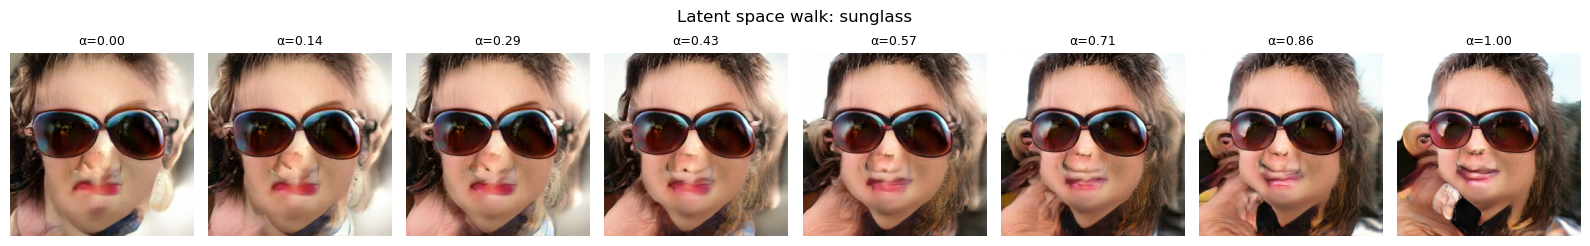

In [50]:
# Explore the images generated by the BigGAN trained model.

import matplotlib.pyplot as plt
from pytorch_pretrained_biggan import convert_to_images

# Latent space exploration: interpolate between two random z vectors
n_images = 8   # <- desired number of images, change freely
name = 'sunglass'

z1 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
z2 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
y  = torch.from_numpy(one_hot_from_names(name, batch_size=1)).to(device)

frames = []
with torch.no_grad():
    for i, alpha in enumerate(torch.linspace(0, 1, n_images)):
        z = (1 - alpha) * z1 + alpha * z2          # linear walk through latent space
        img = model(z, y, truncation=0.4)
        frames.extend(convert_to_images(img.cpu()))  # tensor -> PIL.Image, no disk write

# Display all frames inline as a single row
fig, axes = plt.subplots(1, n_images, figsize=(2 * n_images, 2.5))
for ax, frame, alpha in zip(axes, frames, torch.linspace(0, 1, n_images)):
    ax.imshow(frame)
    ax.set_title(f"α={alpha:.2f}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Latent space walk: {name}", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Latent space exploration: interpolate between two random z vectors
z1 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
z2 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
y = torch.from_numpy(one_hot_from_names(['golden retriever'], batch_size=1)).to(device)

steps = 8
with torch.no_grad():
    for i, alpha in enumerate(torch.linspace(0, 1, steps)):
        z = (1 - alpha) * z1 + alpha * z2 # linear walk through latent space
        img = model(z, y, truncation=0.4)
        save_as_images(img.cpu(), file_name=f"interp_{i}")from pytorch_pretrained_biggan.utils import IMAGENET
from nltk.corpus import wordnet as wn

# Build class index -> human-readable name(s)
idx_to_names = {}
for offset, idx in IMAGENET.items():
    synset = wn.synset_from_pos_and_offset('n', offset)
    # lemma_names() gives every valid string form for this class —
    # any one of these works directly as input to one_hot_from_names()
    idx_to_names[idx] = [n# Latent space exploration: interpolate between two random z vectors
z1 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
z2 = torch.from_numpy(truncated_noise_sample(batch_size=1, dim_z=128, truncation=0.4)).to(device)
y = torch.from_numpy(one_hot_from_names(['golden retriever'], batch_size=1)).to(device)

steps = 8
with torch.no_grad():
    for i, alpha in enumerate(torch.linspace(0, 1, steps)):
        z = (1 - alpha) * z1 + alpha * z2 # linear walk through latent space
        img = model(z, y, truncation=0.4)
        save_as_images(img.cpu(), file_name=f"interp_{i}")ame.replace("_", " ") for name in synset.lemma_names()]

print(f"Total classes: {len(idx_to_names)}")

# Browse the first 20
for idx in range(20):
    print(idx, idx_to_names[idx])

Total classes: 1000
0 ['tench', 'Tinca tinca']
1 ['goldfish', 'Carassius auratus']
2 ['great white shark', 'white shark', 'man-eater', 'man-eating shark', 'Carcharodon carcharias']
3 ['tiger shark', 'Galeocerdo cuvieri']
4 ['hammerhead', 'hammerhead shark']
5 ['electric ray', 'crampfish', 'numbfish', 'torpedo']
6 ['stingray']
7 ['cock']
8 ['hen']
9 ['ostrich', 'Struthio camelus']
10 ['brambling', 'Fringilla montifringilla']
11 ['goldfinch', 'Carduelis carduelis']
12 ['house finch', 'linnet', 'Carpodacus mexicanus']
13 ['junco', 'snowbird']
14 ['indigo bunting', 'indigo finch', 'indigo bird', 'Passerina cyanea']
15 ['robin', 'American robin', 'Turdus migratorius']
16 ['bulbul']
17 ['jay']
18 ['magpie']
19 ['chickadee']


In [49]:
query = "sun"
matches = {idx: names for idx, names in idx_to_names.items()
           if any(query in n.lower() for n in names)}

for idx, names in matches.items():
    print(idx, names)

835 ['sundial']
836 ['sunglass']
837 ['sunglasses', 'dark glasses', 'shades']
838 ['sunscreen', 'sunblock', 'sun blocker']
